In [304]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [305]:
#Importing the dataset
df=pd.read_csv("loan_approval_dataset.csv")

In [306]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [307]:
df.isnull().sum()  # Checking for missing values in the dataset

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [308]:
df.dtypes  # Checking the data types of each column in the dataset

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [309]:
df.select_dtypes(include='object') # Selecting only the categorical columns from the dataset

,education,self_employed,loan_status
0,Graduate,No,Approved
1,Not Graduate,Yes,Rejected
2,Graduate,No,Rejected
3,Graduate,No,Rejected
4,Not Graduate,Yes,Rejected
...,...,...,...
4264,Graduate,Yes,Rejected
4265,Not Graduate,Yes,Approved
4266,Not Graduate,No,Rejected
4267,Not Graduate,No,Approved


In [310]:
pd.set_option('display.float_format', '{:.2f}'.format)  # Setting the option to display all columns in the dataset

In [311]:
df.describe()  # Getting the statistical summary of the dataset

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [312]:
df.shape

(4269, 13)

In [313]:
df.columns.str.strip()  # Stripping the leading and trailing spaces from the column names

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [314]:
df.columns = df.columns.str.strip()

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [316]:
for i in (df.select_dtypes(include='object').columns):
    df[i]=df[i].str.strip()  # Stripping the dataset's categorical column values having spaces

In [317]:
for i in (df.select_dtypes(include='object').columns):
    print(i, ":", df[i].unique())  # Checking the unique values in the categorical columns of the dataset

education : ['Graduate' 'Not Graduate']
self_employed : ['No' 'Yes']
loan_status : ['Approved' 'Rejected']


In [318]:
for i in (df.select_dtypes(include='object').columns):
    print(df[i].value_counts()) # Checking the value counts of the categorical columns in the dataset

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


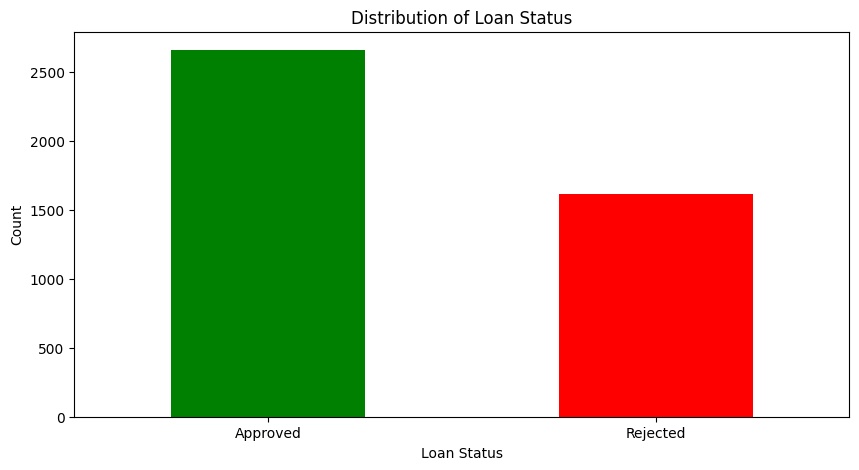

In [319]:
#displaying the count of approved and not approved loans in the dataset
df['loan_status'].value_counts().plot(kind='bar', figsize=(10,5), color=['green', 'red'])
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status')
plt.xticks(rotation=0)
plt.show()

In [320]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [321]:
emp_status = df.groupby(['self_employed', 'loan_status'])['loan_status'].count().unstack()
emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [322]:
emp_status['Total'] = emp_status['Approved'] + emp_status['Rejected']

In [323]:
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


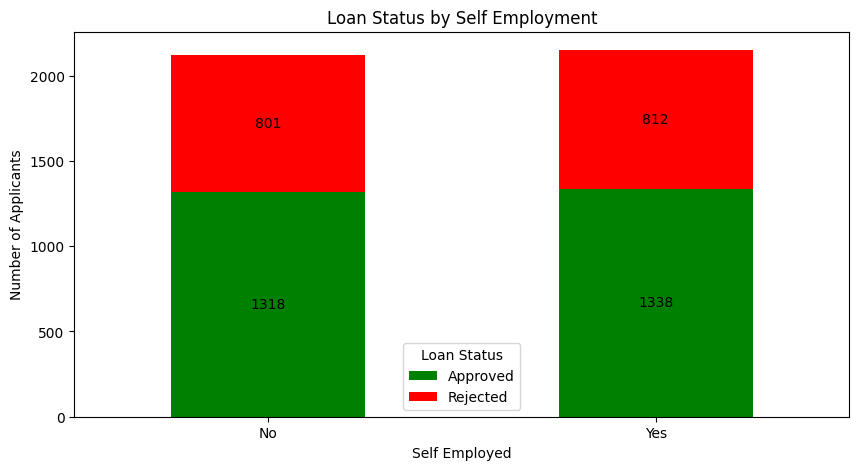

In [324]:
# Plot stacked bar chart
# ax - matplotlib axes object (the chart area)

ax = emp_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True, color = ['green', 'red'], figsize = (10,5))

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax.containers:
    ax.bar_label(container, label_type = 'center')

plt.show()


In [325]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [326]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [327]:
education_status = df.groupby(['education', 'loan_status'])['loan_status'].count().unstack()

education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [328]:
education_status['Total'] = education_status['Approved'] + education_status['Rejected']

In [329]:
education_status

loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125


In [330]:
education_status['Approval_%'] = education_status['Approved'] / education_status['Total'] * 100

In [331]:
education_status

loan_status,Approved,Rejected,Total,Approval_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


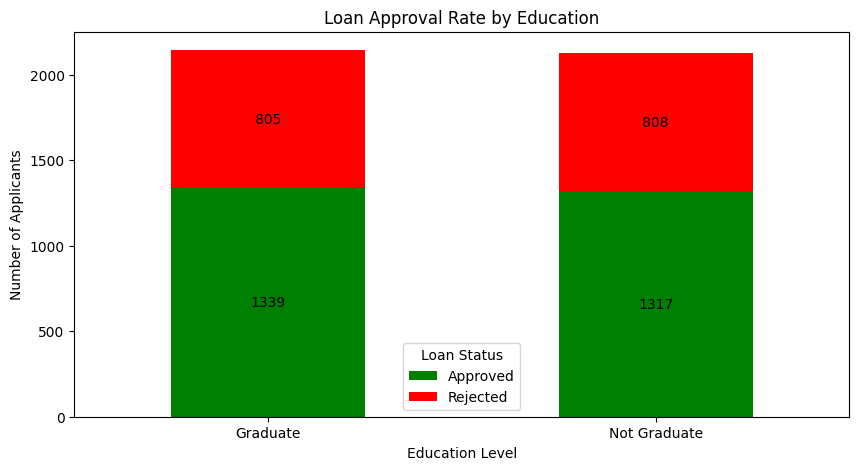

In [332]:
# Plot stacked bar chart

ax1 = education_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True, color = ['green', 'red'], figsize = (10,5))

plt.title("Loan Approval Rate by Education")
plt.ylabel("Number of Applicants")
plt.xlabel("Education Level")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
for container in ax1.containers:
    ax1.bar_label(container, label_type = 'center')
plt.show()


In [333]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [334]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [335]:
dep_status = df.groupby(['no_of_dependents', 'loan_status'])['loan_status'].count().unstack()

dep_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [336]:
dep_status['Total'] = dep_status['Approved'] + dep_status['Rejected']

dep_status

loan_status,Approved,Rejected,Total
no_of_dependents,,,
0,457,255,712
1,430,267,697
2,441,267,708
3,457,270,727
4,465,287,752
5,406,267,673


In [337]:
dep_status['Approval_%'] = dep_status['Approved'] / dep_status['Total'] * 100

dep_status

loan_status,Approved,Rejected,Total,Approval_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


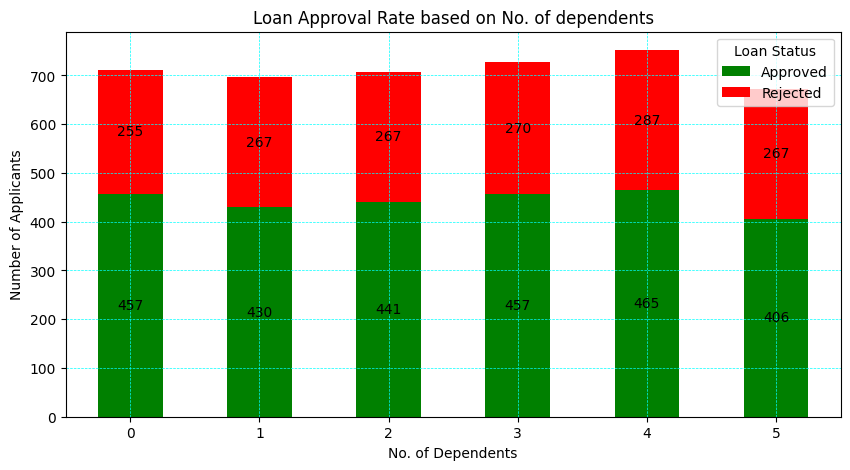

In [338]:
# Plot stacked bar chart

ax2 = dep_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True, color = ['green', 'red'], figsize = (10,5))

plt.title("Loan Approval Rate based on No. of dependents")
plt.ylabel("Number of Applicants")
plt.xlabel("No. of Dependents")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.grid(True, color = 'cyan', linestyle = '--', linewidth = 0.5)

for container in ax2.containers:
    ax2.bar_label(container, label_type = 'center')

plt.show()

In [339]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [340]:
df['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [341]:
x = df.groupby(by = ['loan_status']).mean(numeric_only = True)['income_annum']

x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

<Axes: xlabel='loan_status'>

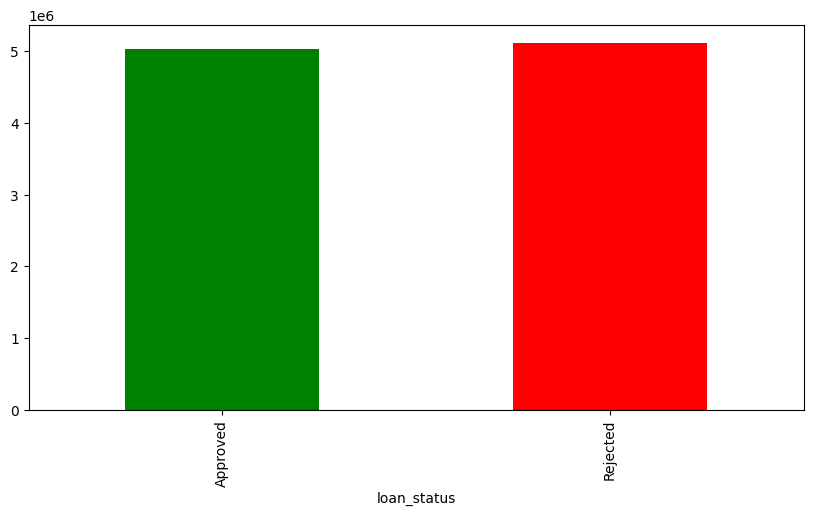

In [342]:
x.plot( kind = 'bar', figsize = (10,5), color = ['green', 'red'])

In [343]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [344]:
df['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [345]:
approved_amount = df[df['loan_status'] == 'Approved']['loan_amount']

approved_amount

0       29900000
6       33000000
8        2200000
10      11200000
13      31500000
          ...   
4261     7500000
4263    12700000
4265    11300000
4267    12800000
4268    29700000
Name: loan_amount, Length: 2656, dtype: int64

In [346]:
rejected_amount = df[df['loan_status'] == 'Rejected']['loan_amount']

rejected_amount

1       12200000
2       29700000
3       30700000
4       24200000
5       13500000
          ...   
4258    22600000
4259    11500000
4262     3000000
4264     2300000
4266    23900000
Name: loan_amount, Length: 1613, dtype: int64

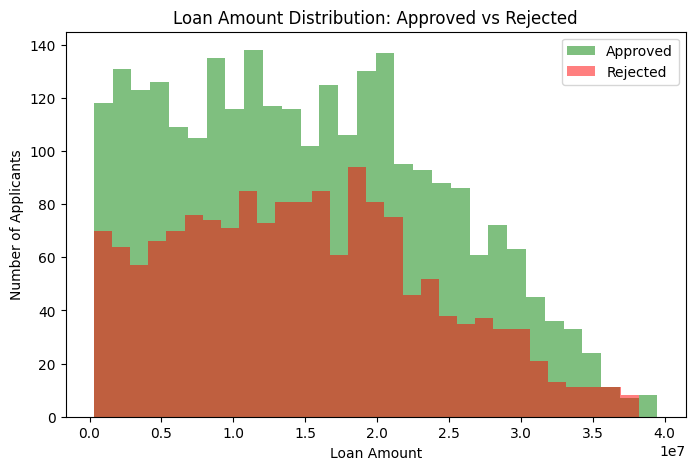

In [347]:
# Plot histogram

plt.figure(figsize = (8,5))

plt.hist( approved_amount, bins = 30, alpha = 0.5, label = 'Approved', color = 'green')
plt.hist( rejected_amount, bins = 30, alpha = 0.5, label = 'Rejected', color = 'red')

plt.title("Loan Amount Distribution: Approved vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

# Approved loans are more concentrated around moderate loan amounts

In [348]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [349]:
df['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [350]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [351]:
# Separate loan amounts

approved_cibil = df[df['loan_status'] == 'Approved']['cibil_score']
rejected_cibil = df[df['loan_status'] == 'Rejected']['cibil_score']

In [352]:
approved_cibil

0       778
6       678
8       782
10      547
13      679
       ... 
4261    881
4263    865
4265    559
4267    780
4268    607
Name: cibil_score, Length: 2656, dtype: int64

In [353]:
rejected_cibil

1       417
2       506
3       467
4       382
5       319
       ... 
4258    346
4259    509
4262    540
4264    317
4266    457
Name: cibil_score, Length: 1613, dtype: int64

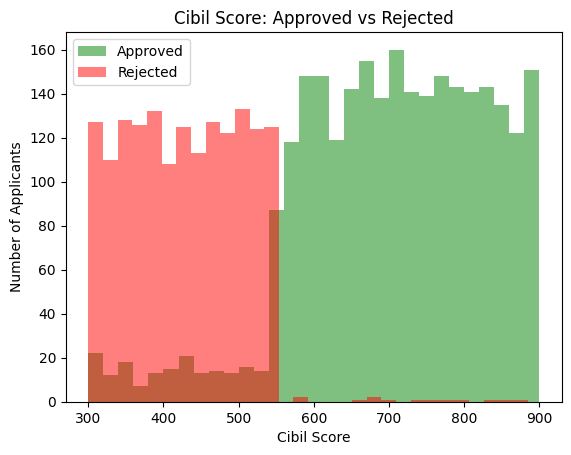

In [354]:
# Plot Histogram

plt.hist(approved_cibil, bins = 30, alpha = 0.5, label = 'Approved', color = 'green')
plt.hist(rejected_cibil, bins = 30, alpha = 0.5, label = 'Rejected', color = 'red')

plt.title("Cibil Score: Approved vs Rejected")
plt.xlabel("Cibil Score")
plt.ylabel("Number of Applicants")
plt.legend()
plt.show()

In [355]:
'''The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges,
while rejected loans are concentrated at lower CIBIL score ranges. This indicates that a higher CIBIL'''

'The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges,\nwhile rejected loans are concentrated at lower CIBIL score ranges. This indicates that a higher CIBIL'

In [356]:
#Compare Applicant Income vs Loan Amount (scatter plot)

In [357]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


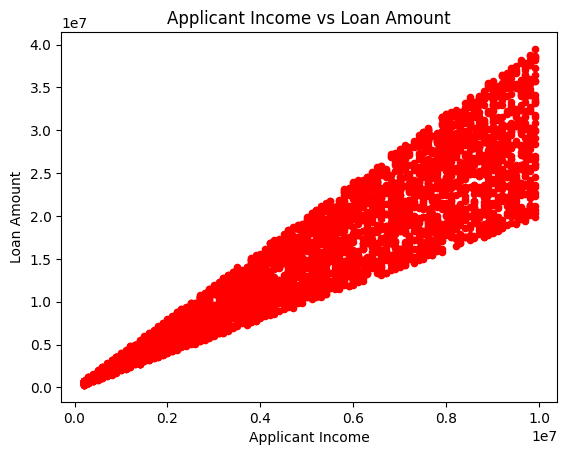

In [358]:
df.plot( x = 'income_annum', y = 'loan_amount', kind = 'scatter', color = 'red')
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

In [359]:
#Compare Applicant Income vs Loan Amount (scatter plot) with color coding based on loan status
#we can clearly see that the approved loans are concentrated in the higher income ranges, while rejected loans are concentrated in the lower income ranges. This indicates that a higher income is associated with a higher likelihood of loan approval.

In [360]:
'Show correlation heatmap of numerical features'

'Show correlation heatmap of numerical features'

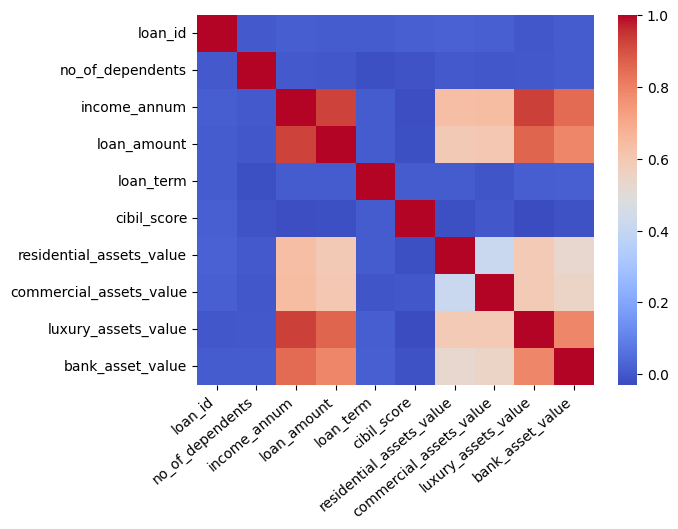

In [361]:
sns.heatmap( df.corr(numeric_only = True), cmap = 'coolwarm' )

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [362]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.9274699109871488)

In [363]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522586)

In [364]:
'Detect Outliers'

'Detect Outliers'

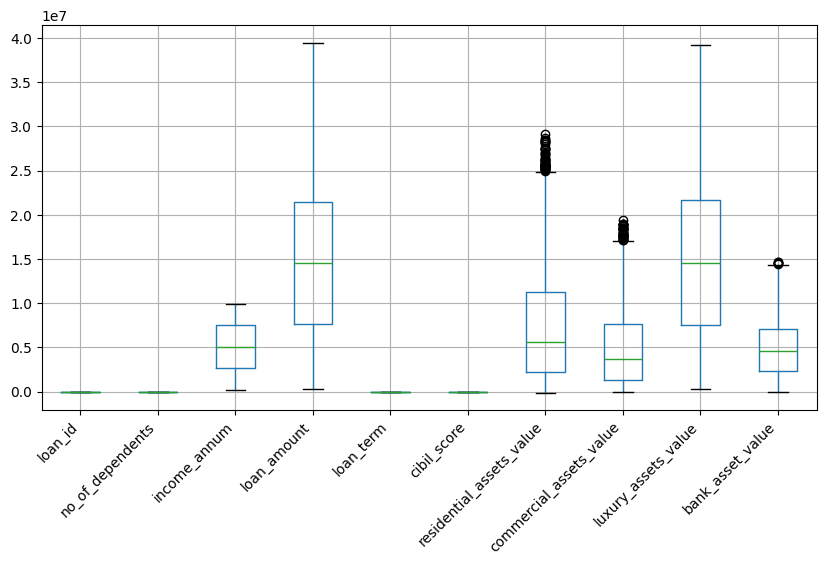

In [365]:
plt.figure(figsize = (10,5))
df.boxplot()
plt.xticks(rotation = 45, ha = 'right')

plt.show()

In [366]:
'Remove Outliers'

'Remove Outliers'

In [367]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [368]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [369]:
# Calculate Quartile

R_Q1 = df['residential_assets_value'].quantile(0.25)
R_Q3 = df['residential_assets_value'].quantile(0.75)

# Calculate IQR
IQR = R_Q3 - R_Q1

In [370]:
IQR

np.float64(9100000.0)

In [371]:
lower_limit = R_Q1 - 1.5 * IQR

upper_limit = R_Q3 + 1.5 * IQR

In [372]:
df = df[(df['residential_assets_value'] >= lower_limit) & (df['residential_assets_value'] <= upper_limit)]

In [373]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


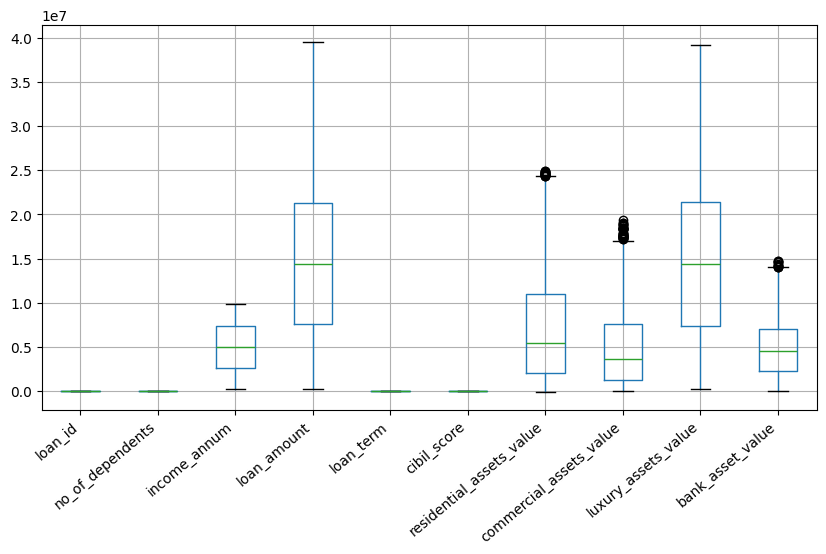

In [374]:
plt.figure(figsize = (10,5))

df.boxplot()

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [375]:
# Calculare Quartile

C_Q1 = df['commercial_assets_value'].quantile(0.25)

C_Q3 = df['commercial_assets_value'].quantile(0.75)


# Calculate IQR

C_IQR = C_Q3 - C_Q1

lower_limit = C_Q1 - 1.5 * C_IQR
upper_limit = C_Q3 + 1.5 * C_IQR

# Lower outlier limit

df = df[(df['commercial_assets_value'] >= lower_limit) & (df['commercial_assets_value'] <= upper_limit)]

In [376]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


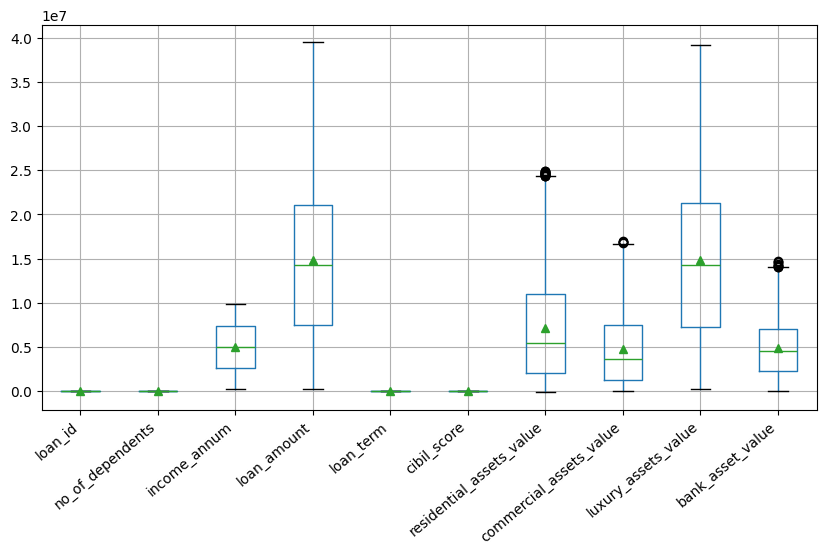

In [377]:
plt.figure(figsize = (10,5))

df.boxplot( showmeans = True )

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [378]:
'Which features should be dropped (like Loan_ID)?'

'Which features should be dropped (like Loan_ID)?'

In [379]:
df = df.drop('loan_id', axis = 1)

In [380]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [381]:
'Convert categorical variables into numeric using Maping, Label Encoding & One Hot Encoding'

'Convert categorical variables into numeric using Maping, Label Encoding & One Hot Encoding'

In [382]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [383]:
#Mapping the target variable 'loan_status' to numeric values (1 for Approved, 0 for Rejected)

df['loan_status'] = df['loan_status'].map({'Approved' : 1, 'Rejected' : 0})

In [384]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


In [385]:
df.select_dtypes(include = 'object').columns

Index(['education', 'self_employed'], dtype='object')

In [386]:
#Label Encoding the categorical variables using sklearn's LabelEncoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['self_employed'] = le.fit_transform(df['self_employed'])

In [387]:
#One Hot Encoding the categorical variables using pandas' get_dummies method

df = pd.get_dummies(df, columns = ['education'])

# This avoids the dummy variable trap and keeps your model clean.

In [388]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


In [389]:
'MODEL BUILDING'

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = df.drop('loan_status', axis = 1)
y = df['loan_status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

models = {"Logistic Regression" : LogisticRegression(max_iter = 1000),
          "Decision Tree" : DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier() 
         }

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy", accuracy_score(y_test, preds) )

Logistic Regression Accuracy 0.7968936678614098
Decision Tree Accuracy 0.9713261648745519
Random Forest Accuracy 0.984468339307049


In [390]:
'Build Random Forest Model'

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators = 200, max_depth = 10, random_state = 39 )

In [391]:
rf_model.fit(X_train, y_train)           #fitting the model on the training data

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [392]:
y_pred = rf_model.predict(X_test)          #predicting the target variable on the test data

In [393]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix          #Evalate the model

print("Accuracy :", accuracy_score(y_test, y_pred) * 100, "%")
print("Classification Report :", classification_report(y_test, y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test, y_pred))

Accuracy : 97.9689366786141 %
Classification Report :               precision    recall  f1-score   support

           0       0.98      0.97      0.97       328
           1       0.98      0.99      0.98       509

    accuracy                           0.98       837
   macro avg       0.98      0.98      0.98       837
weighted avg       0.98      0.98      0.98       837

Confusion Matrix : [[318  10]
 [  7 502]]


In [394]:
feature_importance = pd.Series( rf_model.feature_importances_, index = X.columns ).sort_values(ascending = False)

feature_importance                    #Feature importance of each feature in the dataset based on the Random Forest model

cibil_score                0.83
loan_term                  0.06
loan_amount                0.03
luxury_assets_value        0.02
income_annum               0.02
residential_assets_value   0.02
commercial_assets_value    0.01
bank_asset_value           0.01
no_of_dependents           0.01
self_employed              0.00
education_Graduate         0.00
education_Not Graduate     0.00
dtype: float64

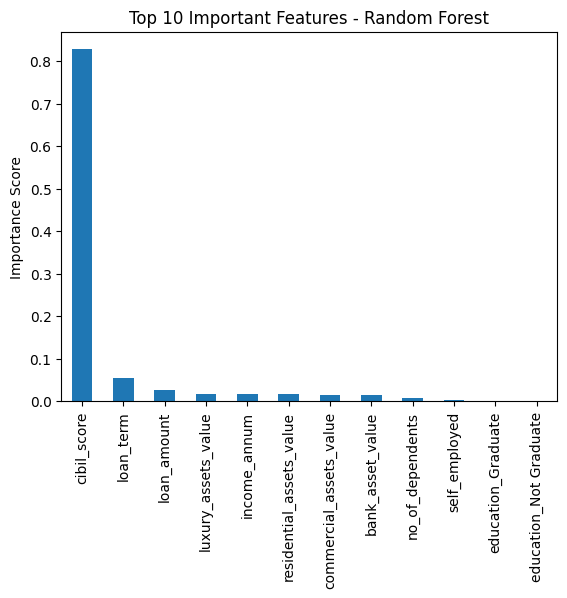

In [395]:
import matplotlib.pyplot as plt
feature_importance.plot(kind = 'bar')
plt.title("Top 10 Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [396]:
'MODEL PREDICTION'

'MODEL PREDICTION'

In [397]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


In [398]:
# For a new customer

new_applicant = {
    'no_of_dependents': 4,
    'self_employed': 1,    
    'income_annum': 600000,
    'loan_amount': 250000,
    'loan_term': 36,
    'cibil_score': 900,
    'residential_assets_value': 30,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 5000,
    'education_Graduate': 1,
    'education_Not Graduate':1,
}

new_df = pd.DataFrame([new_applicant])

In [399]:
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,4,1,600000,250000,36,900,30,0,0,5000,1,1


In [400]:
'PREDICTION' 
pr= rf_model.predict(new_df)

def prediction_result(pr):
    if pr[0] == 1:
        print("Loan Approved")
    else:
        print("Loan Rejected")

In [401]:
prediction_result(pr)

Loan Approved


In [402]:
'SAVE THE MODEL'

import joblib

joblib.dump(rf_model, 'loan_approval_prediction.pkl')

['loan_approval_prediction.pkl']

In [403]:
# Load and Use :

loaded_model = joblib.load('loan_approval_prediction.pkl')

# future_predictions = loaded_model.predict(X_future)

In [404]:
loaded_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
